In [1]:
import torch

In [12]:
x = torch.arange(12) # generate a tensor with 12 elements 0 - 11
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [13]:
x.shape

torch.Size([12])

In [7]:
x.numel() # number of elements

12

In [15]:
x = x.reshape(3, 4) 

In [17]:
torch.zeros((2, 3, 4))

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [18]:
torch.ones((2, 3, 4))

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

In [22]:
x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2,2,2,2])
x + y, x - y, x * y, x / y, x ** y

(tensor([ 3.,  4.,  6., 10.]),
 tensor([-1.,  0.,  2.,  6.]),
 tensor([ 2.,  4.,  8., 16.]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 1.,  4., 16., 64.]))

In [23]:
torch.exp(x)


tensor([2.7183e+00, 7.3891e+00, 5.4598e+01, 2.9810e+03])

In [50]:
X = torch.arange(12, dtype = torch.float32).reshape((3, 4))
Y = torch.tensor([[2.0, 1, 4, 3], [1,2,3,4], [4,3,2,1]])

In [35]:
torch.cat((X, Y), dim = 0) ,  torch.cat((X, Y), dim = 1)


(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [36]:
X == Y 

tensor([[False,  True, False,  True],
        [False, False, False, False],
        [False, False, False, False]])

In [38]:
print(X)
X.sum()

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])


tensor(66.)

In [39]:
# broadcasting mechanism 
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a,b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

In [40]:
a+b

tensor([[0, 1],
        [1, 2],
        [2, 3]])

In [51]:
print(X[-1])  # last row
print(X[1:3]) # rows 1 and 2

tensor([ 8.,  9., 10., 11.])
tensor([[ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])


In [52]:
X[1,2] = 9 # row 1, column 2 (start from 0)
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  9.,  7.],
        [ 8.,  9., 10., 11.]])

In [54]:
X[0:2, 1] = 12 # 'second parameter' is the column index, default is all columns
X

tensor([[ 0., 12.,  2.,  3.],
        [ 4., 12.,  9.,  7.],
        [ 8.,  9., 10., 11.]])

In [58]:
before = id(Y) # like reference in C
Y = Y + X # for prevent Y from being changed | Y[:] = X + Y | Y += X
id(Y) == before


False

In [57]:
Z = torch.zeros_like(Y)
print('id(Z): ', id(Z))
Z[:] = X + Y
Z
print('id(Z): ', id(Z))


id(Z):  2728329437712
id(Z):  2728329437712


In [59]:
A = X.numpy()
B = torch.tensor(A)
type(A) , type(B)

(numpy.ndarray, torch.Tensor)

In [78]:
# data clean (basic)
import os
os.makedirs(os.path.join( 'data'), exist_ok=True)
data_file = os.path.join( 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms, Alley, Price\n') # Column names
    f.write('NA, Pave, 127500\n') # Each row is a data point
    f.write('2, NA, 106000\n')
    f.write('4, NA, 178100\n')
    f.write('NA, NA, 140000\n')

# mock data making

In [79]:
import pandas as pd

data = pd.read_csv(data_file)
data

,NumRooms,Alley,Price
0,NaN,Pave,127500
1,2.0,NA,106000
2,4.0,NA,178100
3,NaN,NA,140000


In [85]:
inputs, outputs = data.iloc[:,  0:1], data.iloc[: , 2] # get all rows , col 0-2 as inputs, and col 2 as outputs
inputs = inputs.fillna(inputs.mean())
# seems like current version of pandas is not supported if fillna with  mean to string column
print(inputs)


   NumRooms
0       3.0
1       2.0
2       4.0
3       3.0


In [103]:
inputs, outputs = data.iloc[:,  0:2], data.iloc[: , 2] # get all rows , col 0-2 as inputs, and col 2 as outputs
inputs = inputs.fillna(inputs.mean(numeric_only=True))
inputs = pd.get_dummies(inputs, dummy_na=True, dtype=float) # one hot encoding
print(inputs)
X,  y = torch.tensor(inputs.values), torch.tensor(outputs.values)
X, y


   NumRooms   Alley_ NA   Alley_ Pave   Alley_nan
0       3.0         0.0           1.0         0.0
1       2.0         1.0           0.0         0.0
2       4.0         1.0           0.0         0.0
3       3.0         1.0           0.0         0.0


(tensor([[3., 0., 1., 0.],
         [2., 1., 0., 0.],
         [4., 1., 0., 0.],
         [3., 1., 0., 0.]], dtype=torch.float64),
 tensor([127500, 106000, 178100, 140000]))

In [104]:
# some basic op about linear algebra in pytorch
import torch

x = torch.tensor([3.0])
y = torch.tensor([2.0])

x + y, x * y, x / y, x ** y



(tensor([5.]), tensor([6.]), tensor([1.5000]), tensor([9.]))

In [106]:
X = torch.arange(4)
X

tensor([0, 1, 2, 3])

In [109]:
X[3], X.shape

(tensor(3), torch.Size([4]))

In [112]:
A =  torch.arange(20).reshape(5,4)
A

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

In [113]:
A.T

tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])

In [114]:
# symettric matrix 
B = torch.tensor([[1,2,3], [2,0,4], [3,4,5]])
B

tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])

In [116]:
B == B.T # all true will show that this is a symettric matrix 

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

In [118]:
A = torch.arange(20, dtype = torch.float32).reshape(5,4)
B = A.clone() # assign a copy of A to B by value, not reference
A , A + B 

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.],
         [24., 26., 28., 30.],
         [32., 34., 36., 38.]]))

In [120]:
A * B # hadamard product  (procuct by element)

tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.],
        [144., 169., 196., 225.],
        [256., 289., 324., 361.]])

In [121]:
a = 2 
X = torch.arange(12, dtype = torch.float32).reshape(3,4)
a + X, a * X, a / X # apply a to each element of X

(tensor([[ 2.,  3.,  4.,  5.],
         [ 6.,  7.,  8.,  9.],
         [10., 11., 12., 13.]]),
 tensor([[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.]]),
 tensor([[   inf, 2.0000, 1.0000, 0.6667],
         [0.5000, 0.4000, 0.3333, 0.2857],
         [0.2500, 0.2222, 0.2000, 0.1818]]))

In [132]:
SUMTEST = torch.arange(24, dtype = torch.float32).reshape(2, 3, 4)
SUMTEST

tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])

In [140]:
SUMTEST.sum(), SUMTEST.shape

(tensor(276.), torch.Size([2, 3, 4]))

In [156]:
SUMTEST.sum(dim = 0) # base on which axis it will be "remove" from the shape


tensor([[12., 14., 16., 18.],
        [20., 22., 24., 26.],
        [28., 30., 32., 34.]])

In [155]:
SUMTEST.sum(axis = 1).shape 

torch.Size([2, 4])

In [143]:
SUMTEST.sum(axis = 2)

tensor([[ 6., 22., 38.],
        [54., 70., 86.]])

In [154]:
x = torch.tensor([1.0, 2, 4, 8])
A.shape, x.shape, torch.mv(A, x), A, A @ x

(torch.Size([5, 4]),
 torch.Size([4]),
 tensor([ 34.,  94., 154., 214., 274.]),
 tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([ 34.,  94., 154., 214., 274.]))

In [152]:
B = torch.ones(4, 3)
A @ B

tensor([[ 6.,  6.,  6.],
        [22., 22., 22.],
        [38., 38., 38.],
        [54., 54., 54.],
        [70., 70., 70.]])

In [158]:
# automatic differentiation
import torch 
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [166]:
x.requires_grad_(True)
x.grad # none for now
#  dot means dot product | 0, 1, 2, 3 * 0, 1, 2, 3 = 0 + 1 + 4 + 9 = 14

tensor([ 0.,  8., 16., 24.])

In [168]:
y = 2 * torch.dot(x, x)
x.grad.zero_()
y.backward()
x.grad, x.grad == 4 * x
# in output grad_fn means y is a result of a function from x and x requires grad is true


(tensor([ 0.,  4.,  8., 12.]), tensor([True, True, True, True]))

In [169]:
x.grad.zero_()
y = x * x 
u = y.detach() # detach means u is not a function of x, treat as a constant, no longer track x's grad
z = u * x
z.sum().backward()
x.grad == u
#!!! backward function is also valid even function is go through other conditions.

tensor([True, True, True, True])

In [1]:
# 李沐 08 Linear regression
import random
import torch
from d2l import torch as d2l

# to generate some data so we know the real W and real b, for practise purpose
def synthetic_data(w, b, num_examples):
    X = torch.normal(0,1,(num_examples, len(w))) # generate X respect to normal distribution center 0 and std 1
    y = torch.matmul(X, w) + b # y = XW + b
    # noise is added to the data
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape([-1,1])

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [2]:
print("features:", features[0], "\nlabel:", labels[0])

features: tensor([ 0.1389, -0.0874]) 
label: tensor([4.7818])


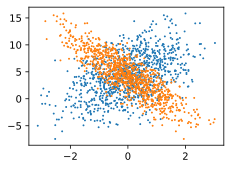

In [3]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 0].detach().numpy(), labels.detach().numpy(), 1);
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

In [5]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]


# TODO: figure what yield actually do, seems like .map() => 
batch_size = 10
# this will generate a random orderd size base on the batch size.
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.1508, -0.4095],
        [-0.7350,  0.6447],
        [ 0.4511,  0.0846],
        [ 0.7162, -1.1934],
        [-1.1470, -0.1281],
        [ 0.7273, -0.1380],
        [-0.1102, -1.1331],
        [ 0.7681,  0.9147],
        [ 2.5162,  0.3253],
        [-0.6699,  1.2558]]) 
 tensor([[ 5.2897],
        [ 0.5515],
        [ 4.8240],
        [ 9.6825],
        [ 2.3473],
        [ 6.1288],
        [ 7.8333],
        [ 2.6352],
        [ 8.1414],
        [-1.3986]])


In [23]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [24]:
def linreg(X, w, b):
    return torch.matmul (X, w) + b

In [25]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

In [26]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [27]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w,b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.035505
epoch 2, loss 0.000127
epoch 3, loss 0.000048


In [30]:
# same implement with pytorch framework lib
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2

# synthetic_data just like what we did above to generate some fake data.
features, labels = d2l.synthetic_data(true_w, true_b, 50)

def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)
next(iter(data_iter))

[tensor([[ 0.9852, -0.6959],
         [ 0.4714, -1.5677],
         [ 1.0733, -0.8808],
         [ 0.0645,  1.5107],
         [ 0.3559,  0.3492],
         [-1.8728,  0.1346],
         [ 1.2183, -0.9872],
         [ 2.6074, -1.1787],
         [-1.2424, -0.7199],
         [-0.7553,  0.3547]]),
 tensor([[ 8.5471e+00],
         [ 1.0470e+01],
         [ 9.3432e+00],
         [-8.1791e-01],
         [ 3.7247e+00],
         [ 1.1651e-02],
         [ 9.9959e+00],
         [ 1.3418e+01],
         [ 4.1451e+00],
         [ 1.4823e+00]])]

In [41]:
# loss func / cross entropy / likelihood function | L2, L1 -> huber's robust Loss 
# likelihood function is saying for a params the possibility that we will see the data like we have now 

In [1]:
# form zero to implement softmax
import torch
from IPython import display
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [2]:
num_inputs = 784 # 28 x 28
num_outputs = 10 # 10 categories

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True) # weight is 784 x 10
b = torch.zeros(num_outputs, requires_grad=True) # for each categories have a bias

In [3]:
# review the tensor sum operation
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [4]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition

In [5]:
# check if our softmax is working 
X = torch.normal(0, 1, (2,5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.1543, 0.7064, 0.0251, 0.0597, 0.0545],
         [0.1828, 0.1928, 0.3016, 0.0701, 0.2527]]),
 tensor([1., 1.]))

In [6]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

In [7]:
# how to extract the label
y = torch.tensor([0,2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0,1], y]

tensor([0.1000, 0.5000])

In [8]:
# create loss function here
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]) # -log in order to give 0 when given value is 1 and bigger number when number is small

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

In [9]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

accuracy(y_hat, y) / len(y)

0.5

In [10]:
def evaluate_accuracy(net, data_iter):
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    for X, y in data_iter:
        metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n # this will create n'th element in array [0.0, 0.0]
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)] # here is a simple function that add numbers to the diff element that created in data

    def reset(self):
        sekf.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

evaluate_accuracy(net, test_iter)

0.0976

In [11]:
def train_epoch_ch3(net, train_iter, loss, update):
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for X, y in train_iter:
        y_hat= net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            updater.step()
            metric.add(float(l) * len(y) , accuracy(y_hat,y), y.size().numel())
        else:
            l.sum().backward()
            updater(X.shape[0])
            metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2],  metric[1] / metric[2]

In [12]:
class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None, ylim=None, xscale='linear', yscale='linear', fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1, figsize=(3.5,2.5)):
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.axes[0].set_position([0,0,0,0])
        self.config_axes()
        self.X, self.Y, self.fmts = None, None, fmts
    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
            

In [13]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    # animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
    #                     legend=['train loss', 'train acc', 'test acc'])
    # display with out animator
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        print(f'epoch {epoch + 1}, train loss: {train_metrics[0]:.3f}, train acc: {train_metrics[1]:.3f}, test acc: {test_acc:.3f}')
        # animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics

In [14]:
lr = 0.1 
def updater(batch_size):
    return d2l.sgd([W,b], lr, batch_size)

num_epochs = 10 
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

epoch 1, train loss: 0.788, train acc: 0.749, test acc: 0.779
epoch 2, train loss: 0.571, train acc: 0.812, test acc: 0.811
epoch 3, train loss: 0.526, train acc: 0.825, test acc: 0.816
epoch 4, train loss: 0.502, train acc: 0.831, test acc: 0.823
epoch 5, train loss: 0.485, train acc: 0.836, test acc: 0.828
epoch 6, train loss: 0.474, train acc: 0.839, test acc: 0.830
epoch 7, train loss: 0.465, train acc: 0.843, test acc: 0.831
epoch 8, train loss: 0.459, train acc: 0.845, test acc: 0.826
epoch 9, train loss: 0.453, train acc: 0.846, test acc: 0.831
epoch 10, train loss: 0.447, train acc: 0.847, test acc: 0.830


In [ ]:
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

In [59]:
loss = nn.CrossEntropyLoss()

In [61]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)